# CS231 - COMPUTER VISION

## Giới thiệu đồ án:
Dự án tập trung vào bài toán Fine-Grained Visual Categorization (FGVC) - phân loại chi tiết 150 loài chim trên tập dữ liệu Birds-525. Áp dụng và so sánh nhiều phương pháp từ truyền thống đến các kiến trúc SOTA (State-of-the-Art) như Bilinear CNN (B-CNN), Vision Transformer (ViT) và CLIP để tìm ra giải pháp tối ưu cho việc nhận diện các đặc trưng nhỏ giữa các loài chim có độ tương đồng cao.

# MEMBER 2:
- Công việc chung (Evaluation & Metrics): Viết script tính toán các độ đo: Accuracy, Precision,Recall,Macro F1.Vẽ Ma trận nhầm lẫn (Confusion Matrix) để phân tích lỗi sâu các loài chim hay bị nhầm với nhau.
- Trích xuất đặc trưng Học sâu: Cài đặt Vision Transformer (ViT-B/16) để trích xuất vector embedding 768 chiều.
- Mô hình phân loại: Random Forest (hoặc SVM) để phân loại dựa trên vector của ViT và Color Histogram.

# Rút trích đặc trưng

## Sử dụng Vision Transformer(ViT) để rút trích đặc trưng:

### Import Thư viện

In [1]:
import os
import numpy as np
import time
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from transformers import AutoImageProcessor, ViTModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tqdm.notebook import tqdm
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")

### Thiết lập cấu hình và Kiểm tra GPU

In [2]:
DATA_DIR = '/kaggle/input/datasets/tonnguynb/augmented-dataset' 
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VALID_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


### Khởi tạo mô hình Vision Transformer (ViT)

In [3]:
MODEL_NAME = "google/vit-base-patch16-224-in21k"
print(f"Đang tải pre-trained model: {MODEL_NAME}...")

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = ViTModel.from_pretrained(MODEL_NAME)

# Đưa model lên GPU và set chế độ evaluation
model = model.to(device)
model.eval() 
print("Tải model thành công!")

Đang tải pre-trained model: google/vit-base-patch16-224-in21k...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Tải model thành công!


### Khai báo Dataset và DataLoaders

In [4]:
class BirdDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.dataset = datasets.ImageFolder(root_dir)
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if image.mode != "RGB":
            image = image.convert("RGB")
            
        # Tự động resize và normalize theo chuẩn ViT
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze()
        return pixel_values, label

BATCH_SIZE = 64

print("Đang cấu hình DataLoaders...")
train_dataset = BirdDataset(TRAIN_DIR, processor)
valid_dataset = BirdDataset(VALID_DIR, processor)
test_dataset = BirdDataset(TEST_DIR, processor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Số lượng class: {len(train_dataset.dataset.classes)}")

Đang cấu hình DataLoaders...
Số lượng class: 150


### Định nghĩa hàm trích xuất đặc trưng

In [5]:
def extract_features(dataloader, desc="Extracting"):
    features = []
    labels = []
    
    with torch.no_grad():
        for batch_images, batch_labels in tqdm(dataloader, desc=desc):
            batch_images = batch_images.to(device)
            
            outputs = model(pixel_values=batch_images)
            
            # Lấy đặc trưng từ token [CLS] (đại diện cho ảnh)
            cls_features = outputs.last_hidden_state[:, 0, :]
            
            features.append(cls_features.cpu().numpy())
            labels.extend(batch_labels.numpy())
            
    return np.vstack(features), np.array(labels)

### Thực thi trích xuất

In [6]:
print("BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG...")

X_train, y_train = extract_features(train_loader, desc="Train set")
X_valid, y_valid = extract_features(valid_loader, desc="Valid set")
X_test, y_test = extract_features(test_loader, desc="Test set")

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Valid: {X_valid.shape}")
print(f"Kích thước tập Test : {X_test.shape}")

BẮT ĐẦU TRÍCH XUẤT ĐẶC TRƯNG...


Train set:   0%|          | 0/469 [00:00<?, ?it/s]

Valid set:   0%|          | 0/67 [00:00<?, ?it/s]

Test set:   0%|          | 0/70 [00:00<?, ?it/s]


Kích thước tập Train: (30000, 768)
Kích thước tập Valid: (4248, 768)
Kích thước tập Test : (4468, 768)


### GridSearch

In [10]:
import numpy as np
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Giả định bạn đã trích xuất đặc trưng (Feature Extraction) xong và đang có dạng mảng (Numpy Array):
# X_train, y_train (Trích xuất từ thư mục 'train')
# X_val, y_val     (Trích xuất từ thư mục 'val')

# --- BƯỚC 1: TẠO BỘ CHIA DỮ LIỆU CỐ ĐỊNH (PREDEFINED SPLIT) ---

# 1.1 Gộp tập Train và Val lại thành một tập chung
X_combined = np.vstack((X_train, X_valid))
y_combined = np.concatenate((y_train, y_valid))

# 1.2 Tạo mảng đánh dấu (test_fold)
# Quy tắc của PredefinedSplit: Index mang giá trị -1 là Train, giá trị 0 là Val
test_fold = np.concatenate([
    np.full(X_train.shape[0], -1),  # Gán toàn bộ data từ folder train thành -1
    np.full(X_valid.shape[0], 0)      # Gán toàn bộ data từ folder val thành 0
])

# 1.3 Khởi tạo bộ chia
ps = PredefinedSplit(test_fold)

# --- BƯỚC 2: ĐƯA VÀO GRIDSEARCH CV ---

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=ps,              # <--- Đổi cv=3 thành cv=ps
    scoring="accuracy",
    verbose=3,
    n_jobs=1
)

# 3. Huấn luyện (Fit) trên tập dữ liệu đã gộp
# GridSearchCV sẽ tự nhìn vào 'test_fold' ở trên để biết cắt đúng phần Val ra để kiểm chứng
grid.fit(X_combined, y_combined)

# In ra kết quả
print(f"\nTham số tốt nhất tìm được: {grid.best_params_}")
print(f"Độ chính xác trên tập Validation cố định: {grid.best_score_:.4f}")

Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.873 total time= 1.4min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.908 total time= 2.7min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100;, score=0.890 total time= 1.4min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=200;, score=0.916 total time= 2.8min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=100;, score=0.874 total time= 1.4min
[CV 1/1] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=5, min_samples_split=2, n_estimators=200;, score=0.911 total time= 2.8min
[CV 1/1] END bootst

### Huấn luyện Random Forest

In [11]:
print("Đang huấn luyện Random Forest...")

# Lấy tham số tốt nhất từ kết quả GridSearch
best_params = grid.best_params_

start = time.time()
# Khởi tạo mô hình Random Forest chính thức
rf_classifier = RandomForestClassifier(
    **best_params,             
    n_jobs=-1,
    random_state=42
)

rf_classifier.fit(X_train, y_train)
train_time = (time.time()-start)/60
print("Huấn luyện hoàn tất!")

Đang huấn luyện Random Forest...
Huấn luyện hoàn tất!


### Đánh giá mô hình (Evaluation)

In [12]:
print("--- KẾT QUẢ ĐÁNH GIÁ ---")

# Validation
y_valid_pred = rf_classifier.predict(X_valid)

acc_val = accuracy_score(y_valid, y_valid_pred)
precision_val = precision_score(y_valid, y_valid_pred, average="macro")
recall_val = recall_score(y_valid, y_valid_pred, average="macro")
f1_val = f1_score(y_valid, y_valid_pred, average="macro")

print("===== VAL =====")
print(f"Accuracy : {acc_val:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall   : {recall_val:.4f}")
print(f"F1-score : {f1_val:.4f}")

# Testing
y_test_pred = rf_classifier.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average="macro")
recall_test = recall_score(y_test, y_test_pred, average="macro")
f1_test = f1_score(y_test, y_test_pred, average="macro")

print("===== TEST =====")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall   : {recall_test:.4f}")
print(f"F1-score : {f1_test:.4f}")


# Mở comment đoạn dưới nếu bạn muốn xem chi tiết (Precision, Recall, F1) cho từng loài chim cụ thể
classes = train_dataset.dataset.classes
print("\nClassification Report trên tập Test:")
print(classification_report(y_test, y_test_pred, target_names=classes))

--- KẾT QUẢ ĐÁNH GIÁ ---
===== VAL =====
Accuracy : 0.9616
Precision: 0.9632
Recall   : 0.9622
F1-score : 0.9617
===== TEST =====
Accuracy : 0.9597
Precision: 0.9613
Recall   : 0.9601
F1-score : 0.9599

Classification Report trên tập Test:
                               precision    recall  f1-score   support

                ABBOTTS BOOBY       0.93      0.97      0.95        29
   ABYSSINIAN GROUND HORNBILL       1.00      0.93      0.96        29
        AFRICAN PIED HORNBILL       1.00      1.00      1.00        30
          AFRICAN PYGMY GOOSE       0.96      0.90      0.93        29
                ALPINE CHOUGH       0.96      0.96      0.96        27
              AMERICAN AVOCET       1.00      1.00      1.00        29
             AMERICAN BITTERN       1.00      1.00      1.00        27
              AMERICAN DIPPER       1.00      1.00      1.00        30
               AMERICAN PIPIT       1.00      1.00      1.00        29
              AMERICAN WIGEON       1.00      1.0

In [13]:
import joblib

joblib.dump(
    rf_classifier,
    "aug_random_forest.pkl"
)

print("RF model saved.")

RF model saved.


### Hàm hỗ trợ phân tích lỗi

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import numpy as np

def get_representative_image(class_name, train_dir=TRAIN_DIR):
    """Lấy ngẫu nhiên một ảnh mẫu của class bị dự đoán nhầm từ tập Train"""
    class_folder = os.path.join(train_dir, class_name)
    if os.path.exists(class_folder):
        images = os.listdir(class_folder)
        if images:
            img_path = os.path.join(class_folder, random.choice(images))
            return Image.open(img_path)
    return None

def analyze_model_results(y_true, y_pred, img_paths, class_names, model_name="Mô hình"):
    """Hàm phân tích và trực quan hóa kết quả đúng/sai"""
    print(f"\n{'='*60}\nPHÂN TÍCH LỖI: {model_name}\n{'='*60}")
    
    correct_idx = np.where(y_true == y_pred)[0]
    incorrect_idx = np.where(y_true != y_pred)[0]
    
    # --- 1. HIỂN THỊ ẢNH ĐOÁN ĐÚNG ---
    print(f"Tổng số ảnh đoán đúng: {len(correct_idx)}")
    num_show_correct = min(5, len(correct_idx))
    
    if num_show_correct > 0:
        fig, axes = plt.subplots(1, num_show_correct, figsize=(20, 4))
        fig.suptitle(f'[{model_name}] VÍ DỤ DỰ ĐOÁN ĐÚNG', fontsize=14, fontweight='bold')
        
        sample_correct = random.sample(list(correct_idx), num_show_correct)
        for i, idx in enumerate(sample_correct):
            img = Image.open(img_paths[idx])
            true_label = class_names[y_true[idx]]
            ax = axes[i] if num_show_correct > 1 else axes
            ax.imshow(img)
            ax.set_title(f"Label: {true_label}", color='green', fontsize=10)
            ax.axis('off')
        plt.show()

    # --- 2. HIỂN THỊ ẢNH ĐOÁN SAI & ẢNH MẪU ĐỂ ĐỐI CHIẾU ---
    print(f"\nTổng số ảnh đoán sai: {len(incorrect_idx)}")
    num_show_incorrect = min(5, len(incorrect_idx))
    
    if num_show_incorrect > 0:
        print("-> Cột Trái: Ảnh bị dự đoán sai | Cột Phải: Ảnh đặc trưng của loài chim bị nhầm lẫn.")
        fig, axes = plt.subplots(num_show_incorrect, 2, figsize=(10, 4 * num_show_incorrect))
        fig.suptitle(f'[{model_name}] PHÂN TÍCH CA SAI LỆCH', fontsize=14, fontweight='bold', y=1.02)
        
        if num_show_incorrect == 1:
            axes = [axes]
            
        sample_incorrect = random.sample(list(incorrect_idx), num_show_incorrect)
        
        for i, idx in enumerate(sample_incorrect):
            img_wrong = Image.open(img_paths[idx])
            true_class = class_names[y_true[idx]]
            pred_class = class_names[y_pred[idx]]
            
            img_representative = get_representative_image(pred_class)
            
            # Vẽ cột trái (Ảnh sai)
            axes[i][0].imshow(img_wrong)
            axes[i][0].set_title(f"THỰC TẾ: {true_class}\n(Model đoán nhầm là: {pred_class})", color='red', fontsize=11)
            axes[i][0].axis('off')
            
            # Vẽ cột phải (Ảnh mẫu)
            if img_representative:
                axes[i][1].imshow(img_representative)
                axes[i][1].set_title(f"ẢNH MẪU CỦA LOÀI:\n{pred_class}", color='blue', fontsize=11)
            else:
                axes[i][1].text(0.5, 0.5, 'Không tìm thấy ảnh mẫu', ha='center')
            axes[i][1].axis('off')
            
        plt.tight_layout()
        plt.show()

### Các ví dụ dự đoán đúng và sai của rút trích đặc trưng theo ViT để train cho Random Forest


PHÂN TÍCH LỖI: VISION TRANSFORMER (ViT)
Tổng số ảnh đoán đúng: 4288


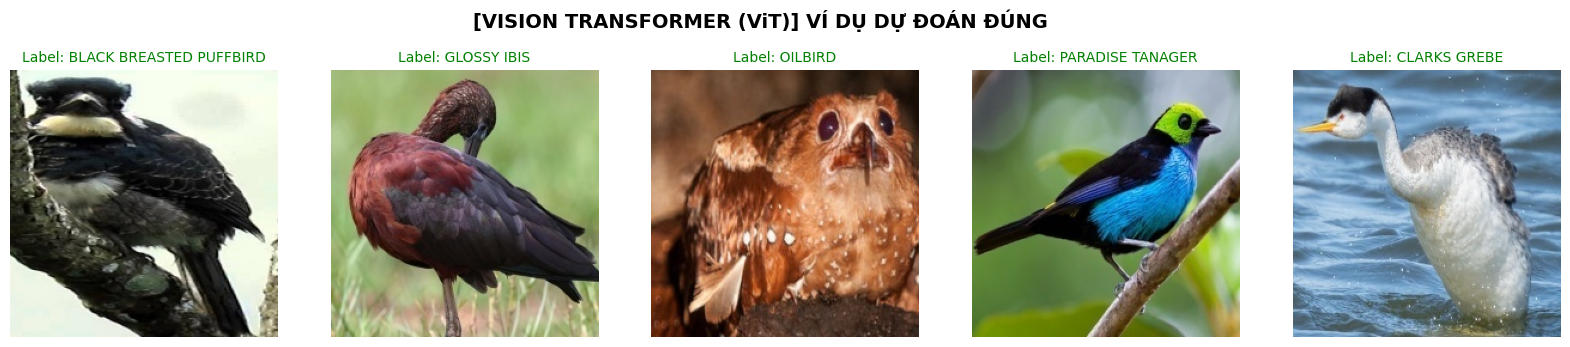


Tổng số ảnh đoán sai: 180
-> Cột Trái: Ảnh bị dự đoán sai | Cột Phải: Ảnh đặc trưng của loài chim bị nhầm lẫn.


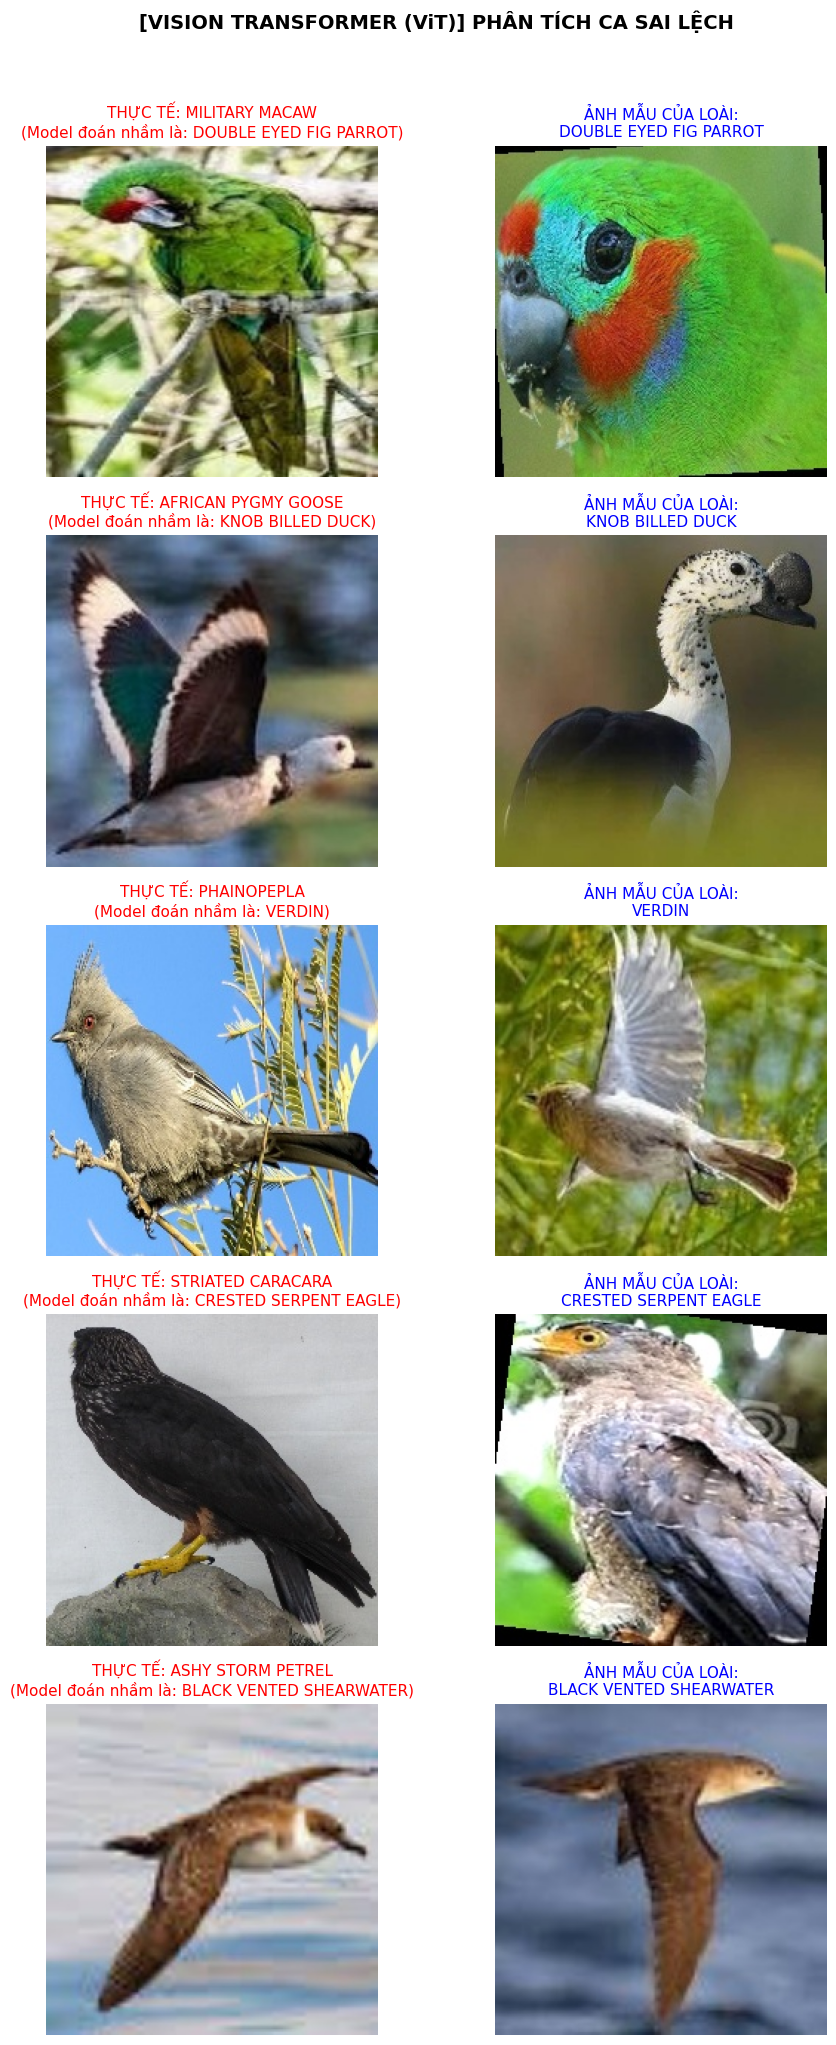

In [16]:
# Lấy danh sách đường dẫn ảnh và tên class (đã có sẵn từ train_dataset/test_dataset)
test_paths_vit = [path for path, label in test_dataset.dataset.imgs]
classes = train_dataset.dataset.classes

# y_test_pred đã được tính ở ngay cell trên (Cell 47)
analyze_model_results(y_test, y_test_pred, test_paths_vit, classes, "VISION TRANSFORMER (ViT)")

## ĐO THỜI GIAN

In [18]:
import time
import torch
import numpy as np
from PIL import Image

# 1. Hàm trích xuất đặc trưng (mặc định dùng GPU nếu có)
def extract_vit_feature(image, device='cuda' if torch.cuda.is_available() else 'cpu'):
    if image.mode != "RGB":
        image = image.convert("RGB")
    
    # Chuẩn bị ảnh và đưa lên thiết bị
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    model.to(device)
    model.eval()
    
    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        # Lấy token [CLS] và đưa về CPU thành dạng numpy array
        features = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
    return features

# 2. Hàm đo extraction time trên cả CPU và GPU
def measure_extraction_time(image, runs=100):
    if image.mode != "RGB":
        image = image.convert("RGB")
        
    # --- ĐO TRÊN CPU ---
    pixel_values_cpu = processor(images=image, return_tensors="pt").pixel_values.to('cpu')
    model.to('cpu') # Ép model về CPU
    model.eval()
    
    cpu_times = []
    with torch.no_grad():
        # Chạy mồi 1 lần
        _ = model(pixel_values=pixel_values_cpu)
        for _ in range(runs):
            start = time.perf_counter()
            _ = model(pixel_values=pixel_values_cpu)
            end = time.perf_counter()
            cpu_times.append(end - start)
            
    cpu_time_ms = np.mean(cpu_times) * 1000
    
    # --- ĐO TRÊN GPU (Nếu có) ---
    gpu_time_ms = None
    if torch.cuda.is_available():
        pixel_values_gpu = processor(images=image, return_tensors="pt").pixel_values.to('cuda')
        model.to('cuda') # Đẩy model lên lại GPU
        
        with torch.no_grad():
            # Warm-up GPU 10 lần để đo chính xác hơn
            for _ in range(10):
                _ = model(pixel_values=pixel_values_gpu)
            torch.cuda.synchronize()
            
            gpu_times = []
            for _ in range(runs):
                start = time.perf_counter()
                _ = model(pixel_values=pixel_values_gpu)
                torch.cuda.synchronize() # Bắt buộc đồng bộ GPU khi đo
                end = time.perf_counter()
                gpu_times.append(end - start)
                
        gpu_time_ms = np.mean(gpu_times) * 1000
        
    return cpu_time_ms, gpu_time_ms

# 3. Hàm đo inference time (Random Forest)
def measure_inference_time_cpu(features, rf_model, runs=100):
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        _ = rf_model.predict(features)
        end = time.perf_counter()
        times.append(end - start)
        
    return np.mean(times) * 1000  # ms

In [19]:
# 1. Lấy đường dẫn của bức ảnh ĐẦU TIÊN trong tập TRAIN
train_image_path = train_dataset.dataset.samples[0][0]

# 2. Đọc ảnh bằng thư viện PIL (đúng biến test_img bạn cần)
test_img = Image.open(train_image_path)
if test_img.mode != "RGB":
    test_img = test_img.convert("RGB")

# 1. Extract feature để có dữ liệu test cho model RF
features = extract_vit_feature(test_img)

# 2. Đo extraction (Hàm này giờ sẽ trả về cả 2 giá trị)
cpu_time, gpu_time = measure_extraction_time(test_img, runs=100)

# 3. Đo inference RF (truyền biến mô hình RF của bạn vào đây, theo ảnh của bạn là rf_vit_org)
inference_time = measure_inference_time_cpu(features, rf_classifier, runs=100)

print("=== RESULTS ===")
print(f"Extraction CPU: {cpu_time:.4f} ms")
print(f"Extraction GPU: {gpu_time:.4f} ms" if gpu_time else "Extraction GPU: No GPU")
print(f"Inference CPU: {inference_time:.4f} ms")

# Biến train_time này chắc bạn đã tính từ lúc train model ở trên, 
# nếu có báo lỗi "not defined" thì bạn kiểm tra lại cell train RF nhé.
print(f"Train time:: {train_time:.4f}m")

=== RESULTS ===
Extraction CPU: 208.9583 ms
Extraction GPU: 15.3205 ms
Inference CPU: 39.9998 ms
Train time:: 4.5501m


In [20]:
import json

# Lấy danh sách nhãn CHUẨN từ thuộc tính classes của ImageFolder
# PyTorch ImageFolder tự động map index 0, 1, 2... theo thứ tự của list này
classes_from_dataset = train_dataset.dataset.classes

with open("label_map.json", "w", encoding="utf-8") as f:
    # Lưu dưới dạng dictionary để map rõ ràng index -> Tên loài (tuỳ chọn nhưng khuyên dùng)
    # hoặc chỉ lưu list như bạn mong muốn
    json.dump(classes_from_dataset, f, ensure_ascii=False, indent=4)
    
print(f"Đã xuất file label_map.json thành công với {len(classes_from_dataset)} loài!")

Đã xuất file label_map.json thành công với 150 loài!
